использование Tensorflow

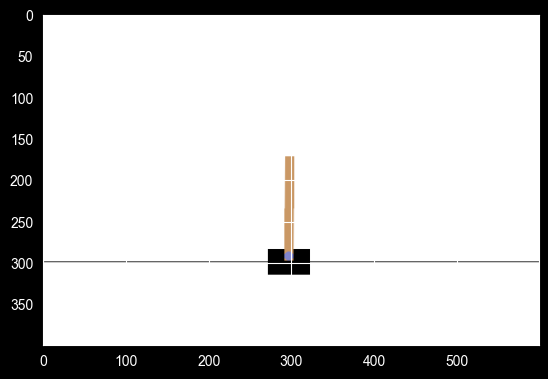

In [1]:
import sys, os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape
img = env.render()
plt.imshow(img)
plt.show()

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()
sess = tf.compat.v1.InteractiveSession()

In [11]:
network = keras.Sequential([
    L.Input(shape=state_dim),
    L.Dense(64, activation='relu'),
    L.Dense(64, activation='relu'),
    L.Dense(int(n_actions), activation='linear')
])

states_input = tf.compat.v1.placeholder(
    tf.float32, shape=(None,) + state_dim, name='states_input'
)

q_values = network(states_input)

sess.run(tf.compat.v1.global_variables_initializer())

In [12]:
def get_action(state, epsilon=0):
    q_vals = sess.run(q_values, feed_dict={states_input: state[None]})[0]
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(q_vals)

проверка

In [13]:
assert network.output_shape == (None, n_actions)
assert network.layers[-1].activation == keras.activations.linear

s, _ = env.reset()
assert np.shape(get_action(s)) == ()

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


Q-обучение через градиентный спуск

In [14]:
# Создание плейсхолдеров для <s, a, r, s'> кортежа и специального индикатора окончания игры (is_done = True)
states_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=(None,) + state_dim)
actions_ph = tf.compat.v1.placeholder(dtype=tf.int32, shape=[None])
rewards_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=[None])
next_states_ph = tf.compat.v1.placeholder(dtype=tf.float32, shape=(None,) + state_dim)
is_done_ph = tf.compat.v1.placeholder(dtype=tf.bool, shape=[None])

#задание q-значений для всех действий в текущем состоянии
predicted_qvalues = network(states_ph)
#выборка q-значений для выбранных действий
predicted_qvalues_for_actions = tf.reduce_sum(predicted_qvalues * tf.one_hot(actions_ph, n_actions), axis=1)

gamma = 0.99

# вычислить q-значения для всех действий в следующих состояниях
predicted_next_qvalues = network(next_states_ph)
# вычислить V * (next_states), используя предсказанные следующие q-значения
next_state_values = tf.reduce_max(predicted_next_qvalues, axis=1)
# вычислить «целевые q-значения» для потерь — это то, что находится внутри квадратных скобок в приведенной выше формуле
target_qvalues_for_actions = rewards_ph + gamma * next_state_values
# в последнем состоянии будем использовать упрощенную формулу: Q(s,a) = r(s,a), так как s' несуществует
target_qvalues_for_actions = tf.where(is_done_ph, rewards_ph, target_qvalues_for_actions)

In [15]:
# потери среднеквадратичной ошибки для минимизации
loss = (predicted_qvalues_for_actions - tf.stop_gradient(target_qvalues_for_actions)) ** 2
loss = tf.reduce_mean(loss)

train_step = tf.compat.v1.train.AdamOptimizer(1e-4).minimize(loss)

assert tf.gradients(loss, [predicted_qvalues_for_actions])[0] is not None, \
    "убедитесь, что вы обновляете q-значения для выбранных действий, а не только для всех действий"
assert tf.gradients(loss, [predicted_next_qvalues])[0] is None, \
    "убедитесь, что вы не распространяете градиент w.r.t. Q_ (c', a')"
assert predicted_next_qvalues.shape.ndims == 2, \
    "убедитесь, что вы предсказали значения q для всех действий в следующем состоянии"
assert next_state_values.shape.ndims == 1, \
    "убедитесь, что вы вычислили V (s') как максимум только по оси действий, а не по всем осям"
assert target_qvalues_for_actions.shape.ndims == 1, \
    "что-то не так с целевыми значениями q, они должны быть вектором"

In [16]:
sess.run(tf.compat.v1.global_variables_initializer())

def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        if train:
            sess.run(train_step, {
                states_ph: [s], actions_ph: [a], rewards_ph: [r],
                next_states_ph: [next_s], is_done_ph: [done]
            })
        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

epsilon = 0.5

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    print("epoch #{}:\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))
    epsilon *= 0.99
    assert epsilon >= 1e-4
    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0:	mean reward = 13.480	epsilon = 0.500
epoch #1:	mean reward = 13.270	epsilon = 0.495
epoch #2:	mean reward = 14.780	epsilon = 0.490
epoch #3:	mean reward = 15.090	epsilon = 0.485
epoch #4:	mean reward = 13.700	epsilon = 0.480
epoch #5:	mean reward = 13.710	epsilon = 0.475
epoch #6:	mean reward = 14.020	epsilon = 0.471
epoch #7:	mean reward = 13.010	epsilon = 0.466
epoch #8:	mean reward = 15.700	epsilon = 0.461
epoch #9:	mean reward = 14.050	epsilon = 0.457
epoch #10:	mean reward = 15.610	epsilon = 0.452
epoch #11:	mean reward = 14.860	epsilon = 0.448
epoch #12:	mean reward = 26.580	epsilon = 0.443
epoch #13:	mean reward = 26.940	epsilon = 0.439
epoch #14:	mean reward = 25.960	epsilon = 0.434
epoch #15:	mean reward = 41.600	epsilon = 0.430
epoch #16:	mean reward = 43.270	epsilon = 0.426
epoch #17:	mean reward = 50.820	epsilon = 0.421
epoch #18:	mean reward = 55.390	epsilon = 0.417
epoch #19:	mean reward = 82.440	epsilon = 0.413
epoch #20:	mean reward = 100.940	epsilon = 0.409
e

использование pytorch

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim[0], 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, n_actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = DQN(state_dim, n_actions).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

In [20]:
def get_action(state, epsilon=0):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)  # (1, state_dim)
        with torch.no_grad():
            q_values = network(state_t).cpu().numpy()[0]
        return np.argmax(q_values)

In [21]:
test_state, _ = env.reset()
test_tensor = torch.FloatTensor(test_state).unsqueeze(0).to(device)
test_output = network(test_tensor)
assert test_output.shape == (1, n_actions), "пожалуйста, убедитесь, что ваша модель \
отображает состояние s -> [Q(s,a0),..., Q(s, a_last)]"
assert not hasattr(network.fc3, 'activation') or network.fc3.activation is None, "пожалуйста, убедитесь, что вы \
предсказываете q-значения без нелинейности"

# проверка эпсилон-жадной стратегии
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for _ in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [22]:
gamma = 0.99

def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            a_t = torch.LongTensor([a]).to(device)
            r_t = torch.FloatTensor([r]).to(device)
            next_s_t = torch.FloatTensor(next_s).unsqueeze(0).to(device) if not done else None
            done_t = torch.BoolTensor([done]).to(device)
            q_sa = network(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
            if not done:
                with torch.no_grad():
                    next_q = network(next_s_t)
                    max_next_q = next_q.max(dim=1)[0]
                target = r_t + gamma * max_next_q
            else:
                target = r_t

            loss = loss_fn(q_sa, target.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

In [23]:
epsilon = 0.5
for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    print("epoch #{}:\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))
    epsilon *= 0.99
    assert epsilon >= 1e-4
    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0:	mean reward = 16.080	epsilon = 0.500
epoch #1:	mean reward = 13.930	epsilon = 0.495
epoch #2:	mean reward = 17.370	epsilon = 0.490
epoch #3:	mean reward = 13.530	epsilon = 0.485
epoch #4:	mean reward = 14.480	epsilon = 0.480
epoch #5:	mean reward = 15.090	epsilon = 0.475
epoch #6:	mean reward = 19.600	epsilon = 0.471
epoch #7:	mean reward = 22.540	epsilon = 0.466
epoch #8:	mean reward = 33.690	epsilon = 0.461
epoch #9:	mean reward = 35.350	epsilon = 0.457
epoch #10:	mean reward = 36.180	epsilon = 0.452
epoch #11:	mean reward = 45.400	epsilon = 0.448
epoch #12:	mean reward = 43.540	epsilon = 0.443
epoch #13:	mean reward = 64.470	epsilon = 0.439
epoch #14:	mean reward = 61.720	epsilon = 0.434
epoch #15:	mean reward = 87.540	epsilon = 0.430
epoch #16:	mean reward = 111.880	epsilon = 0.426
epoch #17:	mean reward = 131.160	epsilon = 0.421
epoch #18:	mean reward = 166.840	epsilon = 0.417
epoch #19:	mean reward = 161.360	epsilon = 0.413
epoch #20:	mean reward = 155.650	epsilon = 0.4